# KKBox 고객 이탈 예측 — LightGBM 모델

| 항목 | 내용 |
|------|------|
| 데이터 | train.csv / val.csv / test.csv |
| 타깃 | `is_churn` (0=유지, 1=이탈) |
| 주요 이슈 | 클래스 불균형 (이탈 ≈ 6.5%) |

**산출물 (result/)**
- `model_performance.csv` — 모델 성능 요약
- `lightgbm_classification_report.csv` — 분류 리포트
- `importance_lightgbm.csv` — 피처 중요도
- `shap_summary.csv` — SHAP 피처 영향도
- `churn_prediction_test.csv` — 회원별 이탈 확률 + 10분위 위험군
- 이미지 4종: `feature_importance_lgbm.png` / `shap_summary.png` / `shap_beeswarm.png` / `risk_decile_distribution.png`

## 0. 라이브러리 & 환경 설정

In [1]:
import os
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    log_loss
)

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows 로컬 환경 기준) ──────────────
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# ── 경로 설정 ─────────────────────────────────────────────
DATA_DIR = './data'      # CSV 파일 위치
RES_DIR  = './result'    # 산출물 저장 위치
MDL_DIR  = './model'     # 모델 저장 위치
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(MDL_DIR, exist_ok=True)

# ── 공통 상수 ─────────────────────────────────────────────
TARGET = 'is_churn'  # 예측 타겟 컬럼
SEED   = 42          # 재현성을 위한 랜덤 시드

# 모델 학습에서 제외할 컬럼
# - msno: 회원 ID (식별자라 의미 없음)
# - 날짜 문자열 원본 3개: 수치형으로 변환된 파생 컬럼이 따로 있음
# - is_churn: 타겟 변수
DROP_COLS = [
    'msno',
    'registration_init_time',
    'tx_transaction_date',
    'tx_membership_expire_date',
    TARGET
]

print(f'   LightGBM {lgb.__version__} | SHAP {shap.__version__}')

   LightGBM 4.6.0 | SHAP 0.52.0


## 1. 데이터 로드

In [2]:
t0 = time.time()

def reduce_mem(df: pd.DataFrame) -> pd.DataFrame:
    """메모리 절감: float64→float32, int64→int32 다운캐스팅"""
    for c in df.select_dtypes('float64').columns:
        df[c] = df[c].astype('float32')
    for c in df.select_dtypes('int64').columns:
        df[c] = df[c].astype('int32')
    return df

# train: 학습용 / val: 검증용 (하이퍼파라미터 튜닝 기준) / test: 최종 평가용
train = reduce_mem(pd.read_csv(os.path.join(DATA_DIR, 'train.csv')))
val   = reduce_mem(pd.read_csv(os.path.join(DATA_DIR, 'val.csv')))
test  = reduce_mem(pd.read_csv(os.path.join(DATA_DIR, 'test.csv')))

print(f'로드 완료 ({time.time()-t0:.1f}s)')
print(f'  train : {train.shape}')
print(f'  val   : {val.shape}')
print(f'  test  : {test.shape}')

# ── 클래스 불균형 확인 ────────────────────────────────────
print('\n[클래스 분포]')
for name, df in [('train', train), ('val', val), ('test', test)]:
    n1 = df[TARGET].sum()              # 이탈 수
    n0 = len(df) - n1                  # 유지 수
    print(f'  {name}: 유지={n0:,}  이탈={n1:,}  이탈율={n1/len(df)*100:.2f}%')

로드 완료 (4.9s)
  train : (435433, 42)
  val   : (145144, 42)
  test  : (145145, 42)

[클래스 분포]
  train: 유지=407,471  이탈=27,962  이탈율=6.42%
  val: 유지=135,824  이탈=9,320  이탈율=6.42%
  test: 유지=135,824  이탈=9,321  이탈율=6.42%


## 2. 전처리

In [3]:
def preprocess(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    X = df[feature_cols].copy()

    # bool 타입 컬럼 → 0/1 정수로 변환 (LightGBM이 bool을 직접 못 받음)
    for c in X.select_dtypes('bool').columns:
        X[c] = X[c].astype(int)

    # 수치형 결측치 → 중앙값으로 대체
    # (평균 대신 중앙값: 이상치 영향을 덜 받음)
    for c in X.select_dtypes('number').columns:
        if X[c].isna().any():
            X[c] = X[c].fillna(X[c].median())

    return X

# DROP_COLS에 없는 컬럼만 피처로 사용
feature_cols = [c for c in train.columns if c not in DROP_COLS]

X_train = preprocess(train, feature_cols)
X_val   = preprocess(val,   feature_cols)
X_test  = preprocess(test,  feature_cols)

y_train = train[TARGET]
y_val   = val[TARGET]
y_test  = test[TARGET]

# ── 클래스 불균형 대응: scale_pos_weight ─────────────────
# 유지(0) 수 / 이탈(1) 수 → 이탈 클래스에 더 높은 가중치 부여
# 예) 14.35 이면 이탈 샘플 1개를 유지 샘플 14개 만큼 중요하게 학습
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'사용 피처 수     : {len(feature_cols)}')
print(f'scale_pos_weight : {scale_pos_weight:.2f}')
print(f'결측치 처리      : 중앙값 대체 완료')

사용 피처 수     : 37
scale_pos_weight : 14.57
결측치 처리      : 중앙값 대체 완료


## 3. 모델 학습

In [4]:
t0 = time.time()

# ── 하이퍼파라미터 설정 ───────────────────────────────────
params = {
    'boosting_type'    : 'gbdt',        # 기본 그래디언트 부스팅
    'objective'        : 'binary',      # 이진 분류
    'metric'           : 'binary_logloss',
    'num_leaves'       : 63,            # 트리 복잡도 (2^depth 보다 유연하게 조절)
    'learning_rate'    : 0.05,          # 학습률 (낮을수록 안정적, 느림)
    'min_child_samples': 50,            # 리프 노드 최소 샘플 수 (과적합 방지)
    'subsample'        : 0.8,           # 매 트리마다 80% 행 샘플링
    'colsample_bytree' : 0.8,           # 매 트리마다 80% 피처 샘플링
    'reg_alpha'        : 0.1,           # L1 정규화
    'reg_lambda'       : 0.1,           # L2 정규화
    'scale_pos_weight' : scale_pos_weight,  # 클래스 불균형 보정
    'verbose'          : -1,            # 학습 로그 끄기
    'seed'             : SEED,
}

# LightGBM 전용 데이터셋 포맷으로 변환
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain)

model = lgb.train(
    params,
    dtrain,
    num_boost_round=500,                # 최대 트리 개수
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=[
        # val logloss가 50번 연속 개선 없으면 조기 종료
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        # 100 라운드마다 로그 출력
        lgb.log_evaluation(period=100),
    ]
)

print(f'\n최적 트리 개수 : {model.best_iteration}')
print(f'학습 소요시간  : {time.time()-t0:.1f}s')

[100]	train's binary_logloss: 0.0862579	val's binary_logloss: 0.0880605
[200]	train's binary_logloss: 0.0747528	val's binary_logloss: 0.0791588
[300]	train's binary_logloss: 0.0664859	val's binary_logloss: 0.0735358
[400]	train's binary_logloss: 0.0599953	val's binary_logloss: 0.0696408
[500]	train's binary_logloss: 0.0546536	val's binary_logloss: 0.0667009

최적 트리 개수 : 500
학습 소요시간  : 8.0s


ImportError: You must install graphviz and restart your session to plot tree.

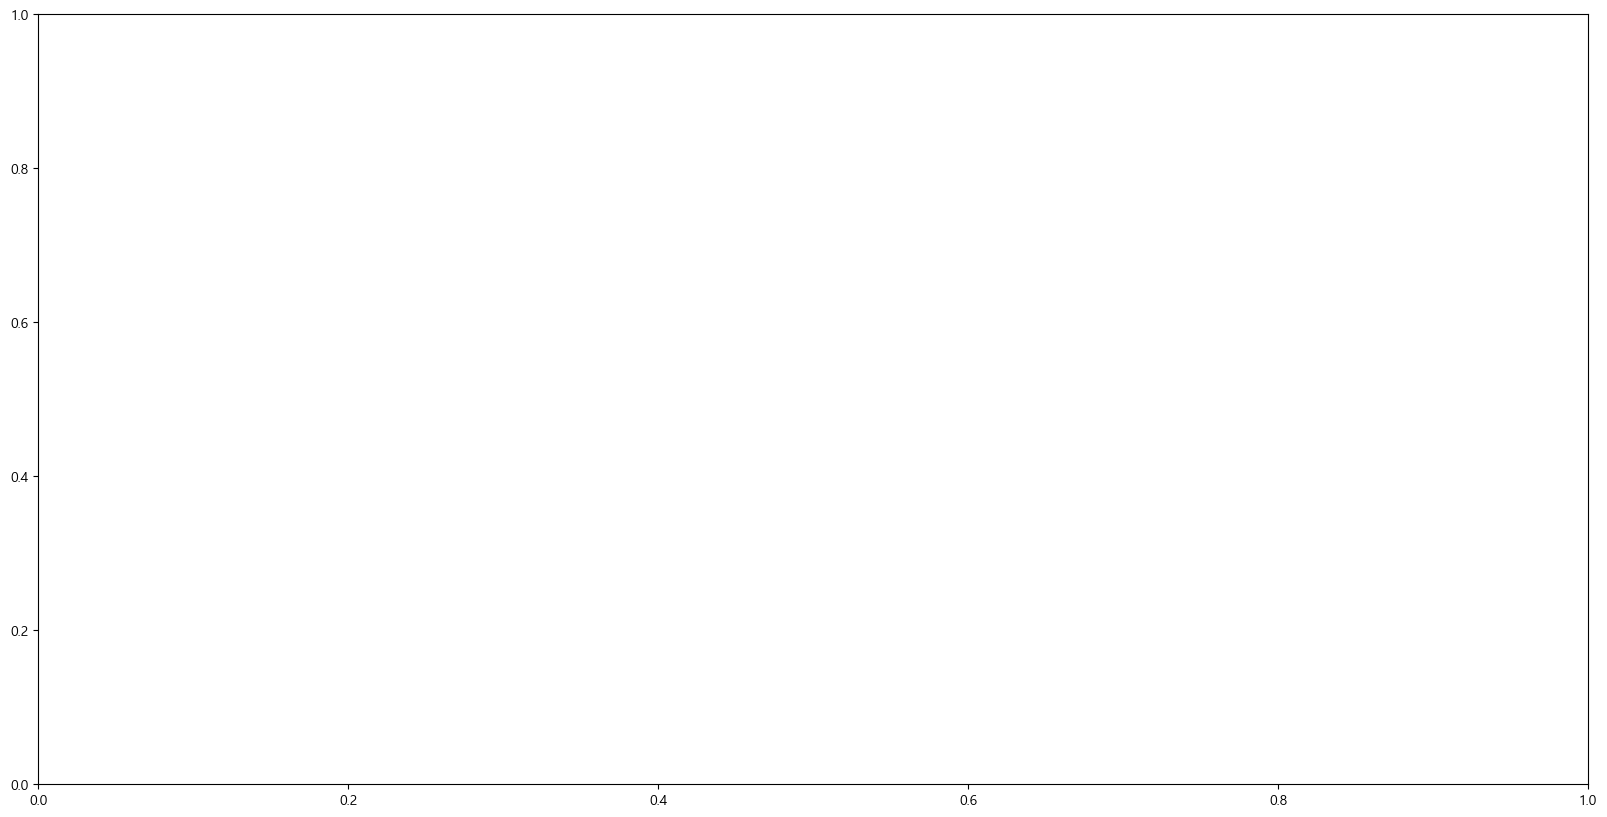

In [6]:
# 특정 트리 하나 시각화 (tree_index로 몇 번째 트리인지 지정)
lgb.plot_tree(model, tree_index=0, figsize=(20, 10))
plt.show()

## 4. 모델 평가

In [ ]:
def evaluate(model, X, y, split_name: str):
    """AUC / F1 / LogLoss 출력 후 pred, proba, 지표값 반환"""
    proba = model.predict(X, num_iteration=model.best_iteration)
    pred  = (proba >= 0.5).astype(int)  # 0.5 기준으로 이진 분류
    auc   = roc_auc_score(y, proba)
    f1    = f1_score(y, pred)
    loss  = log_loss(y, proba)
    print(f'  [{split_name:5s}]  AUC={auc:.6f}  F1={f1:.6f}  LogLoss={loss:.6f}')
    return pred, proba, auc, f1, loss

print('=== 분할별 성능 ===')
evaluate(model, X_train, y_train, 'Train')  # 학습셋 성능 (과적합 체크용)
evaluate(model, X_val,   y_val,   'Val  ')  # 검증셋 성능
test_pred, test_proba, test_auc, test_f1, test_loss = \
    evaluate(model, X_test, y_test, 'Test ')  # 최종 평가

print('\n=== 분류 리포트 (Test) ===')
print(classification_report(y_test, test_pred, target_names=['유지(0)', '이탈(1)']))

## 5. 성능 결과 저장

In [ ]:
# ── 5-1. 모델 성능 요약 CSV ───────────────────────────────
perf_df = pd.DataFrame([{
    'Model'   : 'LightGBM',
    'AUC'     : round(test_auc,  6),
    'F1'      : round(test_f1,   6),
    'Log Loss': round(test_loss, 6),
}])
perf_df.to_csv(f'{RES_DIR}/model_performance.csv', index=False, encoding='utf-8-sig')
print('[저장] result/model_performance.csv')
print(perf_df.to_string(index=False))

# ── 5-2. 분류 리포트 CSV ──────────────────────────────────
report_df = pd.DataFrame(
    classification_report(y_test, test_pred, output_dict=True)
).T
report_df.to_csv(f'{RES_DIR}/lightgbm_classification_report.csv', encoding='utf-8-sig')
print('[저장] result/lightgbm_classification_report.csv')

## 6. 피처 중요도

In [ ]:
# split: 해당 피처가 분기 기준으로 사용된 횟수
# → 많이 쓰일수록 예측에 자주 활용된 중요 피처
imp_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': model.feature_importance(importance_type='split'),
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# CSV 저장
imp_df.to_csv(f'{RES_DIR}/importance_lightgbm.csv', index=False, encoding='utf-8-sig')
print('[저장] result/importance_lightgbm.csv')
print(imp_df.head(10).to_string(index=False))

# ── 시각화 (Top 10) ───────────────────────────────────────
top10 = imp_df.head(10).iloc[::-1]  # 가로 막대 그래프용으로 역순 정렬

plt.figure(figsize=(10, 6))
plt.barh(top10['Feature'], top10['Importance'], color='cornflowerblue')
plt.xlabel('Importance (split count)')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance (LightGBM)')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/feature_importance_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] result/feature_importance_lgbm.png')

## 7. SHAP 분석

SHAP(SHapley Additive exPlanations)은 각 피처가 **개별 예측에 얼마나, 어떤 방향으로** 기여했는지 설명합니다.
- **양수(+)** → 이탈 확률 **증가**에 기여
- **음수(−)** → 이탈 확률 **감소**에 기여
- `mean |SHAP|` 이 클수록 전체 예측에 많은 영향을 준 피처

In [ ]:
t0 = time.time()
print('SHAP 계산 중 (1~2분 소요) ...')

# 전체 테스트셋 대신 샘플링 → 속도 개선
N_SHAP = min(5000, len(X_test))
X_shap = X_test.sample(N_SHAP, random_state=SEED).reset_index(drop=True)

# TreeExplainer: 트리 기반 모델 전용, 빠름
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)  # shape: (샘플 수, 피처 수)

# 피처별 mean |SHAP| → CSV
shap_df = pd.DataFrame({
    'Feature'      : feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_df.to_csv(f'{RES_DIR}/shap_summary.csv', index=False, encoding='utf-8-sig')
print(f'[저장] result/shap_summary.csv  ({time.time()-t0:.1f}s)')
print(shap_df.head(10).to_string(index=False))

In [ ]:
# ── SHAP Bar Plot: 피처별 평균 영향도 ────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_shap,
    plot_type='bar',
    feature_names=feature_cols,
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] result/shap_summary.png')

In [ ]:
# ── SHAP Beeswarm Plot ────────────────────────────────────
# 점 색 = 피처값 크기 (빨강=높음 / 파랑=낮음)
# 가로축 = 이탈 확률에 대한 SHAP 기여값
# → 피처값이 크면 이탈을 높이는지/낮추는지 한눈에 파악 가능
plt.figure()
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_cols,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Feature Value vs Impact')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] result/shap_beeswarm.png')

## 8. 회원별 이탈 확률 예측 + 10분위 위험군 분류

| 컬럼 | 설명 |
|------|------|
| `msno` | 회원 ID |
| `actual_churn` | 실제 이탈 여부 |
| `predicted_churn` | 예측 이탈 여부 (0.5 기준) |
| `churn_probability` | 이탈 확률 (0~1) |
| `risk_decile` | 10분위 위험 등급 (1=최고위험, 10=최저위험) |
| `risk_group` | 3단계 군집 (High / Mid / Low Risk) |

In [ ]:
# 테스트셋 전체 회원에 대한 이탈 확률 예측
proba_full = model.predict(X_test, num_iteration=model.best_iteration)
pred_full  = (proba_full >= 0.5).astype(int)

result = pd.DataFrame({
    'msno'             : test['msno'].values,
    'actual_churn'     : y_test.values,
    'predicted_churn'  : pred_full,
    'churn_probability': proba_full,
})

# ── 10분위 위험 등급 ──────────────────────────────────────
# 이탈 확률 기준으로 10등분 → 확률 높은 구간이 1분위 (최고위험)
result['risk_decile'] = pd.qcut(
    result['churn_probability'],
    q=10,
    labels=list(range(10, 0, -1))  # 10→1 역순 라벨
).astype(int)

# ── 3단계 위험군 ──────────────────────────────────────────
# 1~3분위: High Risk / 4~7분위: Mid Risk / 8~10분위: Low Risk
result['risk_group'] = result['risk_decile'].map(
    lambda d: 'High Risk' if d <= 3 else ('Mid Risk' if d <= 7 else 'Low Risk')
)

# 이탈 확률 높은 순으로 정렬
result = result.sort_values('churn_probability', ascending=False).reset_index(drop=True)

result.to_csv(f'{RES_DIR}/churn_prediction_test.csv', index=False, encoding='utf-8-sig')
print(f'[저장] result/churn_prediction_test.csv  ({len(result):,}명)')

print('\n--- 위험군별 실제 이탈율 ---')
print(result.groupby('risk_group')['actual_churn']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={'count': '회원수', 'sum': '실제이탈수', 'mean': '실제이탈율'}))

print('\n--- 이탈 확률 상위 20명 ---')
print(result.head(20).to_string(index=False))

In [ ]:
# ── Risk Decile 시각화 ────────────────────────────────────
# 막대: 분위별 회원 수 / 선: 실제 이탈율
# → 1분위일수록 실제 이탈율이 높아야 모델이 잘 구분한 것
decile_summary = result.groupby('risk_decile').agg(
    count=('msno', 'count'),
    churn_rate=('actual_churn', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()  # 오른쪽 y축 (이탈율)

# 위험군별 색 구분: High=빨강 / Mid=노랑 / Low=파랑
colors = ['#d73027' if d <= 3 else '#fee090' if d <= 7 else '#91bfdb'
          for d in decile_summary['risk_decile']]

ax1.bar(decile_summary['risk_decile'], decile_summary['count'],
        color=colors, alpha=0.8, label='회원 수')
ax2.plot(decile_summary['risk_decile'], decile_summary['churn_rate'],
         'ko-', linewidth=2, markersize=6, label='실제 이탈율')

ax1.set_xlabel('Risk Decile  (1=최고위험 → 10=최저위험)')
ax1.set_ylabel('회원 수', color='steelblue')
ax2.set_ylabel('실제 이탈율', color='black')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax1.set_xticks(range(1, 11))
plt.title('Risk Decile 분포 vs 실제 이탈율')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(f'{RES_DIR}/risk_decile_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] result/risk_decile_distribution.png')

## 9. 모델 저장 & 산출물 확인

In [ ]:
# 모델 저장 (나중에 lgb.Booster(model_file=...) 로 불러올 수 있음)
model.save_model(f'{MDL_DIR}/lightgbm_tuned.txt')
print(f'[저장] model/lightgbm_tuned.txt')

print('\n========== 최종 산출물 목록 ==========')
for f in sorted(os.listdir(RES_DIR)):
    fpath = os.path.join(RES_DIR, f)
    print(f'  {f:45s}  {os.path.getsize(fpath)/1024:.1f} KB')

print('\n✅ 전체 완료')